# Three-Way Comparison: EBM vs NAM vs GAM

Statistical comparison of EBM, NAM, and GAM performance across 10 regression and 10 classification datasets.

This notebook:
1. Displays performance summary tables for all three models
2. Performs Friedman test to check if models differ significantly
3. If significant, performs Nemenyi post-hoc test to identify which model is best


In [9]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
from sklearn.datasets import fetch_openml

# Project root
project_root = Path().resolve().parent.parent
results_dir = project_root / 'results' / 'evaluation'

def get_dataset_names(dataset_ids, task_type):
    """Get dataset names from OpenML for given dataset IDs."""
    dataset_names = {}
    for ds_id in dataset_ids:
        try:
            dataset = fetch_openml(data_id=ds_id, as_frame=True, parser='auto')
            dataset_names[ds_id] = dataset.details['name']
        except Exception as e:
            dataset_names[ds_id] = f"Dataset_{ds_id}"
    return dataset_names


In [10]:
# Dataset IDs
regression_datasets = [41021, 44956, 44957, 44958, 44959, 44966, 44972, 44980, 44987, 45402]
classification_datasets = [31, 37, 50, 1049, 1050, 1063, 1067, 1068, 1462, 1464]

# Get dataset names
regression_names = get_dataset_names(regression_datasets, 'regression')
classification_names = get_dataset_names(classification_datasets, 'classification')
print("Regression datasets:", regression_names)
print("\nClassification datasets:", classification_names)


Regression datasets: {41021: 'Moneyball', 44956: 'abalone', 44957: 'airfoil_self_noise', 44958: 'auction_verification', 44959: 'concrete_compressive_strength', 44966: 'solar_flare', 44972: 'red_wine', 44980: 'kin8nm', 44987: 'socmob', 45402: 'space_ga'}

Classification datasets: {31: 'credit-g', 37: 'diabetes', 50: 'tic-tac-toe', 1049: 'pc4', 1050: 'pc3', 1063: 'kc2', 1067: 'kc1', 1068: 'pc1', 1462: 'banknote-authentication', 1464: 'blood-transfusion-service-center'}


In [11]:
def load_metrics(dataset_ids, task_type, metric_name, silent=False, dataset_names=None):
    """Load metrics, optionally print table, return arrays and DataFrame."""
    ebm_all, nam_all, gam_all, rows = [], [], [], []
    if dataset_names is None:
        dataset_names = {ds_id: f"Dataset_{ds_id}" for ds_id in dataset_ids}
    for ds_id in dataset_ids:
        fps = {m: results_dir / f"{m.lower()}_OpenML_{ds_id}_{task_type}_performance.json" for m in ['EBM', 'NAM', 'GAM']}
        metrics = {m: np.array([f['metric_value'] for f in json.load(open(fp))['folds']]) if fp.exists() else None for m, fp in fps.items()}
        if all(metrics[m] is not None for m in ['EBM', 'NAM', 'GAM']):
            ebm_all.extend(metrics['EBM']); nam_all.extend(metrics['NAM']); gam_all.extend(metrics['GAM'])
        row = {'Dataset ID': ds_id, 'Dataset Name': dataset_names.get(ds_id, f"Dataset_{ds_id}")}
        for m in ['EBM', 'NAM', 'GAM']:
            row[f'{m} Mean'] = metrics[m].mean() if metrics[m] is not None else np.nan
            row[f'{m} Std'] = metrics[m].std() if metrics[m] is not None else np.nan
        rows.append(row)
    df = pd.DataFrame(rows)
    if not silent:
        display_df = pd.DataFrame({
            'Dataset ID': df['Dataset ID'],
            'Dataset Name': df['Dataset Name'],
            **{f'{m} ({metric_name})': df.apply(lambda r: f"{r[f'{m} Mean']:.4f} ± {r[f'{m} Std']:.4f}" if not np.isnan(r[f'{m} Mean']) else 'N/A', axis=1) for m in ['EBM', 'NAM', 'GAM']}
        })
        print("=" * 100, f"\n{task_type.upper()}: Performance Summary ({metric_name} ({'lower' if task_type == 'regression' else 'higher'} is better))", "=" * 100, "\nPer-Dataset Results:", display_df.to_string(index=False), "=" * 100, sep='\n')
    return np.array(ebm_all), np.array(nam_all), np.array(gam_all), df


In [12]:
# Load metrics (silent)
ebm_reg, nam_reg, gam_reg, regression_table = load_metrics(regression_datasets, 'regression', 'RMSE', silent=False, dataset_names=regression_names)
ebm_clf, nam_clf, gam_clf, classification_table = load_metrics(classification_datasets, 'classification', 'AUC', silent=False, dataset_names=classification_names)



REGRESSION: Performance Summary (RMSE (lower is better))

Per-Dataset Results:
 Dataset ID                  Dataset Name           EBM (RMSE)           NAM (RMSE)           GAM (RMSE)
      41021                     Moneyball     22.2727 ± 1.1289     20.0171 ± 1.5311     21.0136 ± 1.0848
      44956                       abalone      2.2073 ± 0.1505      2.2490 ± 0.1378      2.1255 ± 0.1155
      44957            airfoil_self_noise      1.9019 ± 0.1240      4.5958 ± 0.1138      4.5717 ± 0.1660
      44958          auction_verification 2389.8668 ± 136.5650 5955.3791 ± 198.7538 5268.7065 ± 203.5554
      44959 concrete_compressive_strength      4.1624 ± 0.4047      5.4784 ± 0.3739      5.4298 ± 0.5180
      44966                   solar_flare      0.8658 ± 0.0668      0.7701 ± 0.0576      0.7885 ± 0.0631
      44972                      red_wine      0.5903 ± 0.0267      0.6242 ± 0.0335      0.6459 ± 0.0371
      44980                        kin8nm      0.1645 ± 0.0030      0.1980 ± 0.0

## Initial Friedman Test

Quick check if models differ significantly before detailed comparison.


In [13]:
def run_friedman_test(table, task_name):
    """Run Friedman test on per-dataset means and print results."""
    # For Friedman test, we need per-dataset means (blocks)
    # Remove rows with NaN values
    table_clean = table[['EBM Mean', 'NAM Mean', 'GAM Mean']].dropna()
    
    if len(table_clean) < 3:
        print(f"\n{task_name}: Cannot perform test (insufficient datasets, need at least 3)")
        return
    
    # Prepare data for Friedman test (per-dataset means)
    ebm_means = table_clean['EBM Mean'].values
    nam_means = table_clean['NAM Mean'].values
    gam_means = table_clean['GAM Mean'].values
    
    friedman_stat, friedman_pval = friedmanchisquare(ebm_means, nam_means, gam_means)
    print(f"\n{task_name}:")
    print(f"  Statistic: {friedman_stat:.4f}")
    print(f"  p-value: {friedman_pval:.6f}")
    print(f"  Significant (α=0.05): {'Yes' if friedman_pval < 0.05 else 'No'}")
    if friedman_pval < 0.05:
        print(f"  → Models differ significantly. Proceed with detailed comparison.")
    else:
        print(f"  → No significant difference between models.")

# Load metrics for Friedman test (need table for per-dataset means)
_, _, _, regression_table = load_metrics(regression_datasets, 'regression', 'RMSE', silent=True)
_, _, _, classification_table = load_metrics(classification_datasets, 'classification', 'AUC', silent=True)

print("=" * 70)
print("FRIEDMAN TEST: Overall Significance Check")
print("=" * 70)

run_friedman_test(regression_table, 'REGRESSION')
run_friedman_test(classification_table, 'CLASSIFICATION')

print("=" * 70)


FRIEDMAN TEST: Overall Significance Check

REGRESSION:
  Statistic: 2.4000
  p-value: 0.301194
  Significant (α=0.05): No
  → No significant difference between models.

CLASSIFICATION:
  Statistic: 3.2308
  p-value: 0.198814
  Significant (α=0.05): No
  → No significant difference between models.


## Detailed Three-Way Comparison

If Friedman test is significant, detailed comparison with Nemenyi post-hoc test follows.


In [14]:
def run_statistical_test(task_type, table):
    """Run paired Wilcoxon signed-rank tests: NAM vs EBM and NAM vs GAM."""
    print("=" * 70)
    print(f"{task_type.upper()}: Paired Wilcoxon Signed-Rank Tests")
    print("=" * 70)
    
    # Get per-dataset means (remove rows with NaN values)
    table_clean = table[['EBM Mean', 'NAM Mean', 'GAM Mean']].dropna()
    
    if len(table_clean) < 3:
        print("Cannot perform tests: insufficient datasets (need at least 3)")
        return
    
    # Prepare data for Wilcoxon tests (per-dataset means)
    ebm_means = table_clean['EBM Mean'].values
    nam_means = table_clean['NAM Mean'].values
    gam_means = table_clean['GAM Mean'].values
    
    # Perform paired Wilcoxon signed-rank tests: NAM vs EBM and NAM vs GAM
    stat_nam_ebm, pval_nam_ebm = wilcoxon(nam_means, ebm_means, alternative='two-sided')
    stat_nam_gam, pval_nam_gam = wilcoxon(nam_means, gam_means, alternative='two-sided')
    
    # Apply Bonferroni correction (2 tests)
    pvals = [pval_nam_ebm, pval_nam_gam]
    comparisons = ['NAM vs EBM', 'NAM vs GAM']
    
    # Multiple testing correction
    rejected, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')
    
    for comp, pval_raw, pval_corr, is_sig in zip(comparisons, pvals, pvals_corrected, rejected):
        sig_marker = "***" if is_sig else ""
        print(f"  {comp}: p={pval_raw:.6f}, p_corrected={pval_corr:.6f}{sig_marker}")
    
    print("=" * 70)

# Run Wilcoxon tests (data already loaded in previous cell)
run_statistical_test('regression', regression_table)
print()
run_statistical_test('classification', classification_table)


REGRESSION: Paired Wilcoxon Signed-Rank Tests
  NAM vs EBM: p=0.492188, p_corrected=0.984375
  NAM vs GAM: p=0.193359, p_corrected=0.386719

CLASSIFICATION: Paired Wilcoxon Signed-Rank Tests
  NAM vs EBM: p=0.130859, p_corrected=0.261719
  NAM vs GAM: p=0.845703, p_corrected=1.000000


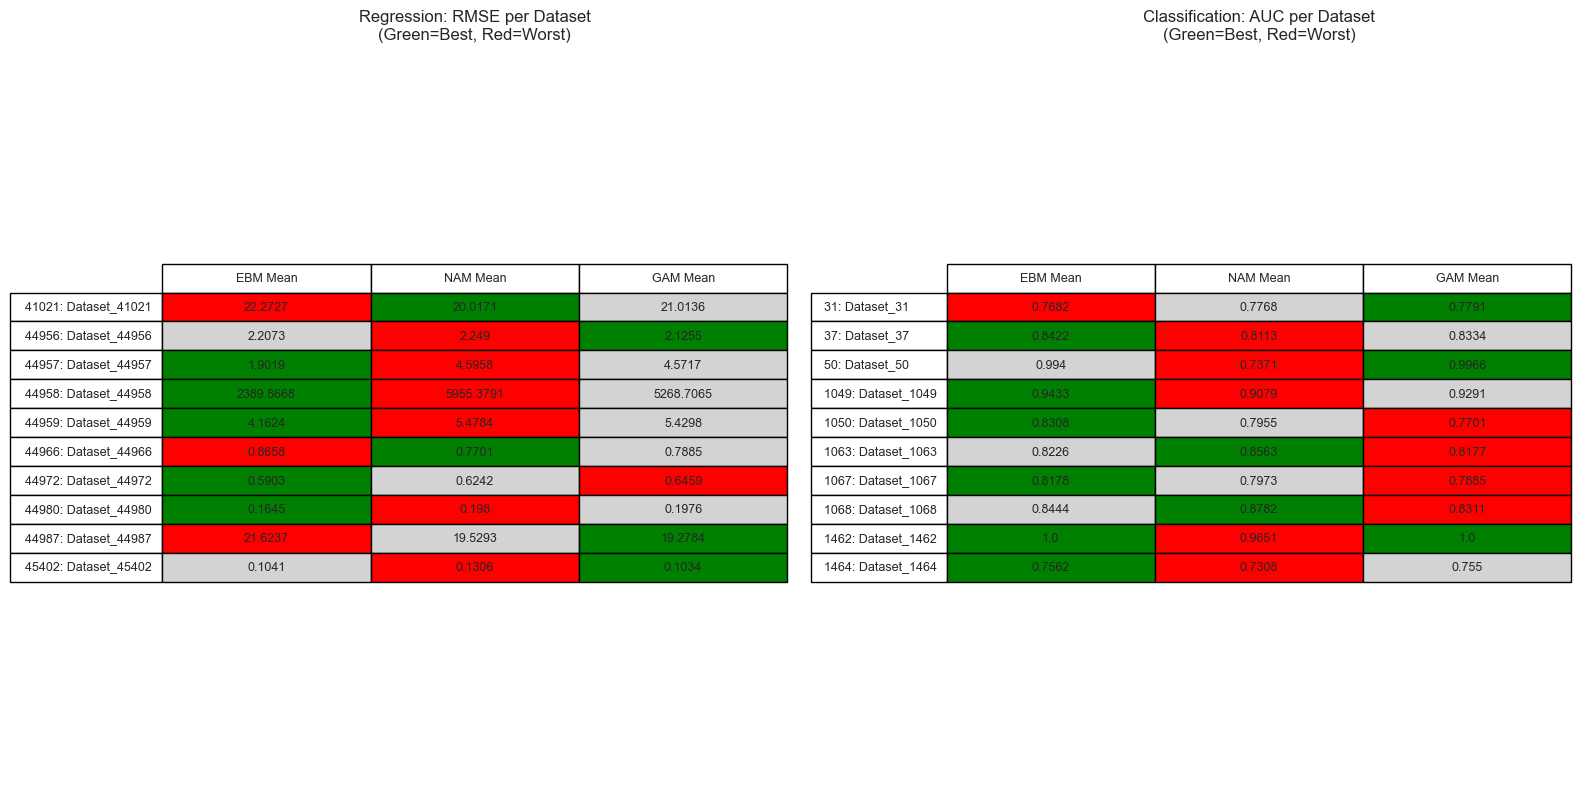

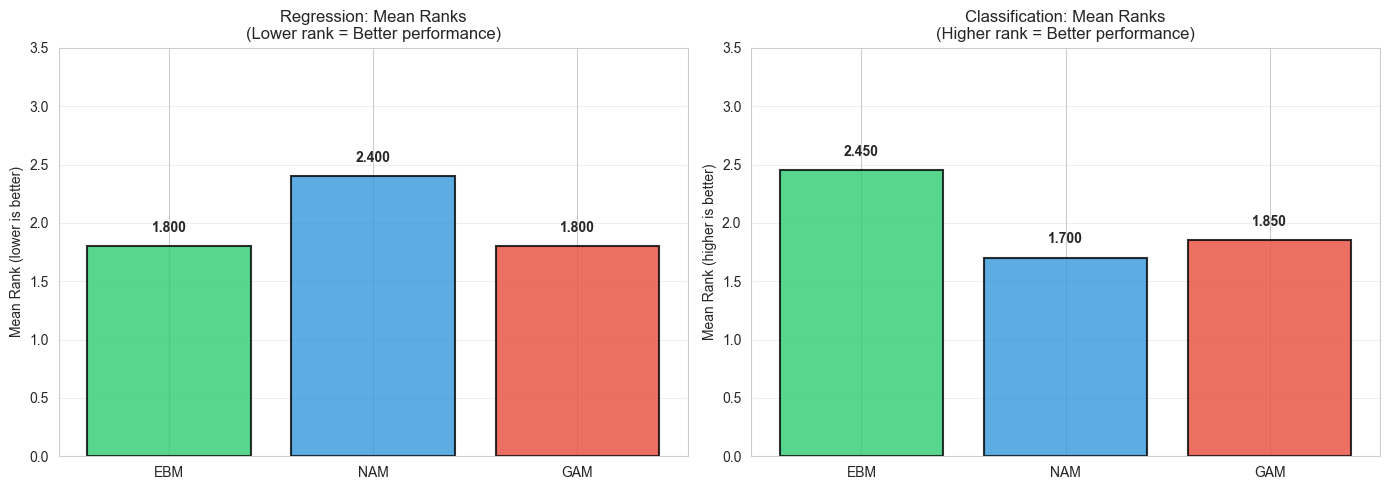

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# 1. Color-coded Tables
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Regression table
ax1 = axes[0]
reg_display = regression_table[['Dataset ID', 'Dataset Name', 'EBM Mean', 'NAM Mean', 'GAM Mean']].copy()
reg_display['Label'] = reg_display.apply(lambda row: f"{row['Dataset ID']}: {row['Dataset Name'][:30]}", axis=1)
reg_display = reg_display[['EBM Mean', 'NAM Mean', 'GAM Mean']].copy()
reg_display.index = regression_table.apply(lambda row: f"{row['Dataset ID']}: {row['Dataset Name'][:30]}", axis=1)
# Color code: green for best (lowest RMSE), red for worst (highest RMSE)
reg_colors = reg_display.apply(lambda row: ['green' if val == row.min() else 'red' if val == row.max() else 'lightgray' for val in row], axis=1, result_type='expand')
reg_colors.columns = reg_display.columns
ax1.axis('tight')
ax1.axis('off')
table1 = ax1.table(cellText=reg_display.round(4).values, 
                   rowLabels=reg_display.index, 
                   colLabels=reg_display.columns,
                   cellColours=reg_colors.values,
                   cellLoc='center', loc='center')
table1.auto_set_font_size(False)
table1.set_fontsize(9)
table1.scale(1.2, 1.5)
ax1.set_title('Regression: RMSE per Dataset\n(Green=Best, Red=Worst)', pad=20)

# Classification table
ax2 = axes[1]
clf_display = classification_table[['Dataset ID', 'Dataset Name', 'EBM Mean', 'NAM Mean', 'GAM Mean']].copy()
clf_display['Label'] = clf_display.apply(lambda row: f"{row['Dataset ID']}: {row['Dataset Name'][:30]}", axis=1)
clf_display = clf_display[['EBM Mean', 'NAM Mean', 'GAM Mean']].copy()
clf_display.index = classification_table.apply(lambda row: f"{row['Dataset ID']}: {row['Dataset Name'][:30]}", axis=1)
# Color code: green for best (highest AUC), red for worst (lowest AUC)
clf_colors = clf_display.apply(lambda row: ['green' if val == row.max() else 'red' if val == row.min() else 'lightgray' for val in row], axis=1, result_type='expand')
clf_colors.columns = clf_display.columns
ax2.axis('tight')
ax2.axis('off')
table2 = ax2.table(cellText=clf_display.round(4).values, 
                   rowLabels=clf_display.index, 
                   colLabels=clf_display.columns,
                   cellColours=clf_colors.values,
                   cellLoc='center', loc='center')
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1.2, 1.5)
ax2.set_title('Classification: AUC per Dataset\n(Green=Best, Red=Worst)', pad=20)

plt.tight_layout()
plt.show()

# 2. Mean Ranks Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate mean ranks for regression
reg_ranks = []
for idx, row in regression_table.iterrows():
    values = [row['EBM Mean'], row['NAM Mean'], row['GAM Mean']]
    if not any(np.isnan(values)):
        ranks = rankdata(values, method='average')
        reg_ranks.append(ranks)
reg_mean_ranks = np.array(reg_ranks).mean(axis=0)

# Calculate mean ranks for classification
clf_ranks = []
for idx, row in classification_table.iterrows():
    values = [row['EBM Mean'], row['NAM Mean'], row['GAM Mean']]
    if not any(np.isnan(values)):
        ranks = rankdata(values, method='average')
        clf_ranks.append(ranks)
clf_mean_ranks = np.array(clf_ranks).mean(axis=0)

# Regression mean ranks
ax1 = axes[0]
models = ['EBM', 'NAM', 'GAM']
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars1 = ax1.bar(models, reg_mean_ranks, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Mean Rank (lower is better)')
ax1.set_title('Regression: Mean Ranks\n(Lower rank = Better performance)')
ax1.set_ylim(0, 3.5)
ax1.grid(axis='y', alpha=0.3)
for i, (bar, rank) in enumerate(zip(bars1, reg_mean_ranks)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{rank:.3f}', ha='center', va='bottom', fontweight='bold')

# Classification mean ranks
ax2 = axes[1]
bars2 = ax2.bar(models, clf_mean_ranks, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Mean Rank (higher is better)', fontsize=12)
ax2.set_title('Classification: Mean Ranks\n(Higher rank = Better performance)', fontsize=14)
ax2.set_ylim(0, 3.5)
ax2.grid(axis='y', alpha=0.3)
for i, (bar, rank) in enumerate(zip(bars2, clf_mean_ranks)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{rank:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

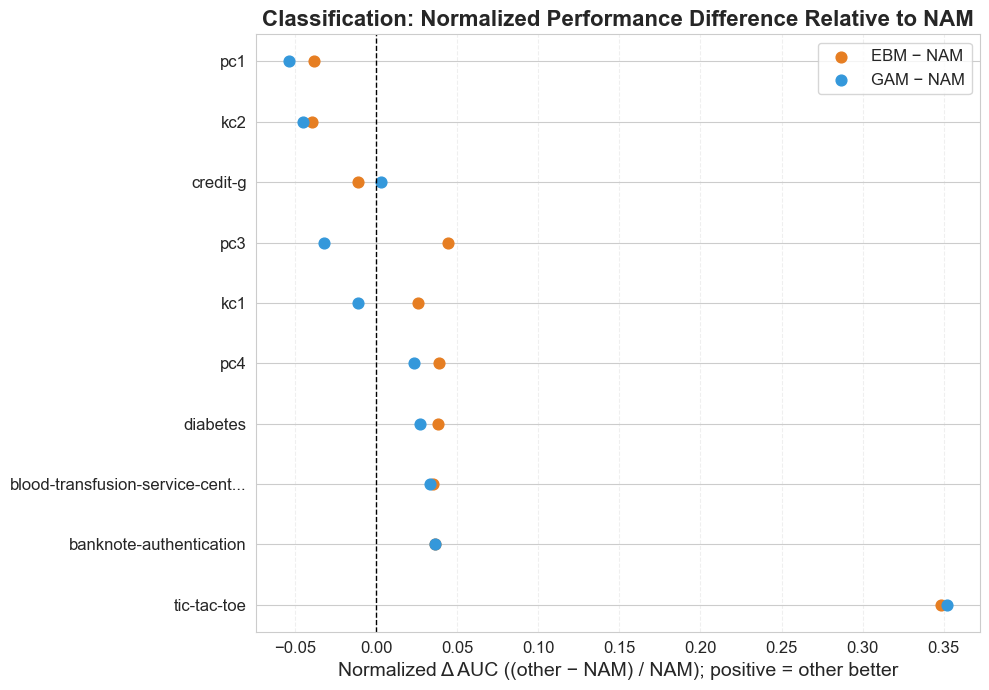

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df = classification_table[
    ['Dataset ID', 'Dataset Name', 'EBM Mean', 'NAM Mean', 'GAM Mean']
].dropna()

# Normalized deltas: (other - NAM) / NAM (positive = other has higher AUC = other better)
nam_mean = df['NAM Mean'].replace(0, np.nan)
df['EBM - NAM'] = (df['EBM Mean'] - df['NAM Mean']) / nam_mean
df['GAM - NAM'] = (df['GAM Mean'] - df['NAM Mean']) / nam_mean
df = df.dropna(subset=['EBM - NAM', 'GAM - NAM']).reset_index(drop=True)

# Order by signed normalized Δ (primary comparison): mean of (EBM−NAM)/NAM and (GAM−NAM)/NAM
# Descending: others beat NAM (positive) at top, NAM beats others (negative) at bottom
df['primary_delta'] = (df['EBM - NAM'] + df['GAM - NAM']) / 2
df = df.sort_values('primary_delta', ascending=False).reset_index(drop=True)

y = np.arange(len(df))

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df['EBM - NAM'], y, color='#e67e22', label='EBM − NAM', s=60)
ax.scatter(df['GAM - NAM'], y, color='#3498db', label='GAM − NAM', s=60)

# Reference line
ax.axvline(0, color='black', linestyle='--', linewidth=1)

ax.set_yticks(y)
# Use names from classification_names (no IDs); truncate long names for readability
dataset_labels = [classification_names.get(ds_id, f"Dataset_{ds_id}") for ds_id in df['Dataset ID']]
dataset_labels = [str(name)[:30] + ('...' if len(str(name)) > 30 else '') for name in dataset_labels]
ax.set_yticklabels(dataset_labels, fontsize=12)
ax.set_xlabel('Normalized Δ AUC ((other − NAM) / NAM); positive = other better', fontsize=14)
ax.set_title('Classification: Normalized Performance Difference Relative to NAM', fontsize=16, fontweight='bold')

ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.legend(fontsize=12)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()


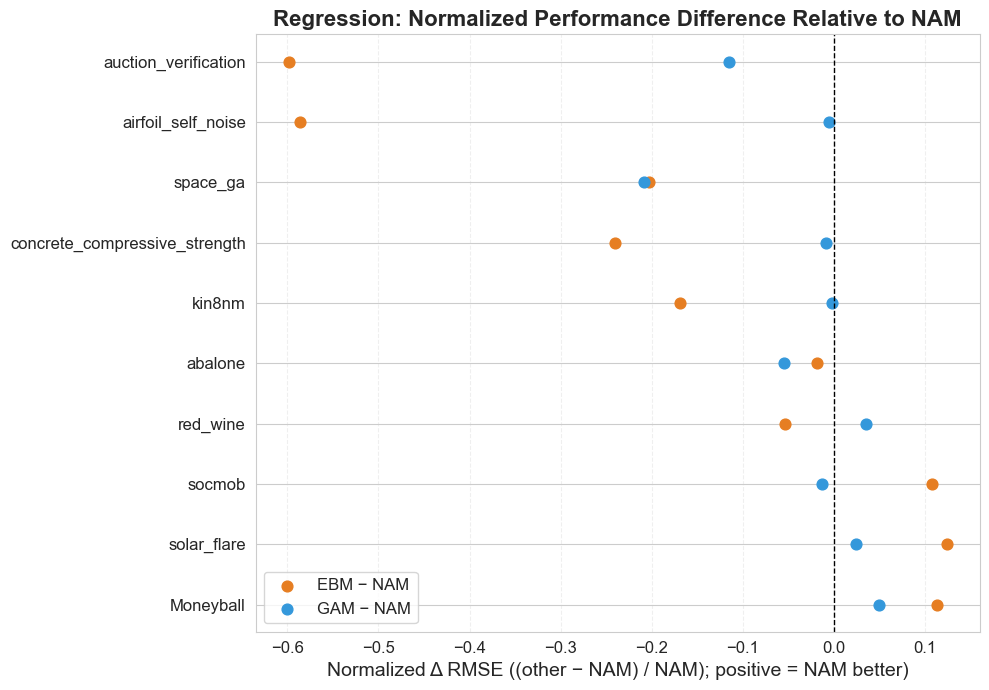

In [32]:
# Regression: Performance difference relative to NAM (RMSE; positive = NAM better)
import matplotlib.pyplot as plt
import numpy as np

df_reg = regression_table[
    ['Dataset ID', 'Dataset Name', 'EBM Mean', 'NAM Mean', 'GAM Mean']
].dropna()

# Normalized deltas: (other - NAM) / NAM (positive = other has higher RMSE = NAM better)
nam_mean = df_reg['NAM Mean'].replace(0, np.nan)
df_reg['EBM - NAM'] = (df_reg['EBM Mean'] - df_reg['NAM Mean']) / nam_mean
df_reg['GAM - NAM'] = (df_reg['GAM Mean'] - df_reg['NAM Mean']) / nam_mean
df_reg = df_reg.dropna(subset=['EBM - NAM', 'GAM - NAM']).reset_index(drop=True)

# Order by signed normalized Δ (primary comparison): mean of (EBM−NAM)/NAM and (GAM−NAM)/NAM
# Descending: NAM better (positive) at top, others better (negative) at bottom
df_reg['primary_delta'] = (df_reg['EBM - NAM'] + df_reg['GAM - NAM']) / 2
df_reg = df_reg.sort_values('primary_delta', ascending=False).reset_index(drop=True)

y_reg = np.arange(len(df_reg))

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df_reg['EBM - NAM'], y_reg, color='#e67e22', label='EBM − NAM', s=60)
ax.scatter(df_reg['GAM - NAM'], y_reg, color='#3498db', label='GAM − NAM', s=60)

ax.axvline(0, color='black', linestyle='--', linewidth=1)

ax.set_yticks(y_reg)
dataset_labels_reg = [regression_names.get(ds_id, f"Dataset_{ds_id}") for ds_id in df_reg['Dataset ID']]
dataset_labels_reg = [str(name)[:30] + ('...' if len(str(name)) > 30 else '') for name in dataset_labels_reg]
ax.set_yticklabels(dataset_labels_reg, fontsize=12)
ax.set_xlabel('Normalized Δ RMSE ((other − NAM) / NAM); positive = NAM better)', fontsize=14)
ax.set_title('Regression: Normalized Performance Difference Relative to NAM', fontsize=16, fontweight='bold')

ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.legend(fontsize=12)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()